In [1]:
# ogbn-arxiv robust test

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from torch_geometric.nn import GATConv, MessagePassing
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import matplotlib.pyplot as plt

# ==========================================
# 0. 鲁棒性全局配置
# ==========================================
NOISE_RATIOS = [0.0, 0.05, 0.10, 0.15, 0.20] # 噪声比例
TEST_SEED = 1227

# ==========================================
# 1. 核心架构组件 (完全保留你的原始定义)
# ==========================================
class Config: # 继承主脚本参数
    hidden_dim = 128; proj_dim = 256; hops = 2; epochs = 100 # 鲁棒性测试建议100轮确保收敛
    soft_end = 40; lr_init = 0.001; batch_size = 512
    target_sparsity = 0.30; lambda_max = 1.0; link_weight = 0.4; weight_decay = 5e-4

class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)
    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i, z_j = self.proj(h_i), self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        self.gat1 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gat2 = GATConv(self.total_hidden, hidden_size, heads=8, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = nn.Sequential(nn.Linear(self.total_hidden*2, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(self.total_hidden, hidden_size*4), nn.BatchNorm1d(hidden_size*4),
                                        nn.ReLU(), nn.Dropout(0.3), nn.Linear(hidden_size*4, out_size))
        self.hops, self.tau = hops, tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        active_nodes = start_mask.float()
        final_weights = torch.zeros(edge_index.size(1), device=edge_index.device)
        for _ in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(h.size(0), device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x); y_emb = self.label_emb(y_label); x_fused = x_proj + y_emb 
        h1 = F.elu(self.bn1(self.gat1(x_fused, edge_index)) + y_emb) 
        h_base = F.elu(self.bn2(self.gat2(h1, edge_index)) + x_proj) 
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            h_enhanced = F.elu(self.bn_enh(h_enhanced + self.enhancer(h_enhanced, edge_index, weights))) 
        return F.log_softmax(self.classifier(h_enhanced), dim=1), self.link_predictor(torch.cat([h_enhanced[edge_index[0]], h_enhanced[edge_index[1]]], -1)).squeeze(), h_enhanced, weights, logits_raw.detach()

# --- Baseline GAT ---
class GAT_Vanilla(torch.nn.Module):
    def __init__(self, in_size, head_dim, num_heads, out_size):
        super().__init__()
        self.res_lin = nn.Linear(in_size, head_dim * num_heads)
        self.conv1 = GATConv(head_dim * num_heads, head_dim, heads=num_heads, dropout=0.5)
        self.bn1 = nn.BatchNorm1d(head_dim * num_heads)
        self.conv2 = GATConv(head_dim * num_heads, head_dim, heads=num_heads, dropout=0.5)
        self.bn2 = nn.BatchNorm1d(head_dim * num_heads)
        self.classifier = nn.Sequential(nn.Linear(head_dim*num_heads, head_dim*num_heads//2),
                                        nn.BatchNorm1d(head_dim*num_heads//2), nn.ReLU(),
                                        nn.Dropout(0.3), nn.Linear(head_dim*num_heads//2, out_size))
    def forward(self, x, edge_index):
        x_p = self.res_lin(x)
        x = F.elu(self.bn1(self.conv1(x_p, edge_index)))
        x = F.elu(self.bn2(self.conv2(x, edge_index))) + x_p
        return F.log_softmax(self.classifier(x), dim=1)

# ==========================================
# 2. 实验核心逻辑 (注入噪声与独立训练)
# ==========================================
def inject_structure_noise(edge_index, num_nodes, noise_rate):
    if noise_rate <= 0: return edge_index
    num_noise = int(edge_index.size(1) * noise_rate)
    noise_edges = negative_sampling(edge_index, num_nodes=num_nodes, num_neg_samples=num_noise)
    return torch.cat([edge_index, noise_edges], dim=1)

def run_experiment(m_type, noise_rate, data, split_idx, device, evaluator):
    # 注入噪声
    noisy_edges = inject_structure_noise(data.edge_index, data.num_nodes, noise_rate)
    noisy_edges, _ = add_self_loops(noisy_edges, num_nodes=data.num_nodes)
    data.edge_index = noisy_edges

    # 完全保留你的 Loader 逻辑 (workers=4)
    train_loader = NeighborLoader(data, num_neighbors=[20, 15], batch_size=Config.batch_size, 
                                  input_nodes=split_idx['train'], shuffle=True, num_workers=4, persistent_workers=True)
    test_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, 
                                 input_nodes=split_idx['test'], shuffle=False, num_workers=4, persistent_workers=True)

    if m_type == 'Ours':
        model = NeuralRecursiveSystem(data.num_features, 128, 40).to(device)
        optimizer = torch.optim.Adam([
            {'params': [p for n, p in model.named_parameters() if 'sampler_net' not in n], 'lr': Config.lr_init},
            {'params': model.sampler_net.parameters(), 'lr': Config.lr_init * 0.1}
        ], weight_decay=Config.weight_decay)
    else:
        model = GAT_Vanilla(data.num_features, 128, 8, 40).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)

    best_test_acc = 0
    for epoch in range(1, Config.epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            if m_type == 'Ours':
                y_in = batch.y.squeeze().clone(); y_in[:batch.batch_size] = 40
                mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device); mask[:batch.batch_size] = True
                lp, link_pos, h_enh, ws, _ = model(batch.x, batch.edge_index, y_in, mask, hard=(epoch > Config.soft_end))
                # 完整保留你的 Loss 逻辑
                loss = F.nll_loss(lp[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
                neg_e = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
                link_neg = model.link_predictor(torch.cat([h_enh[neg_e[0]], h_enh[neg_e[1]]], -1)).squeeze()
                loss += Config.link_weight * (F.binary_cross_entropy(link_pos, torch.ones_like(link_pos)) + F.binary_cross_entropy(link_neg, torch.zeros_like(link_neg)))
                loss += Config.lambda_max * F.l1_loss(ws.mean(), torch.tensor(Config.target_sparsity, device=device))
            else:
                out = model(batch.x, batch.edge_index)
                loss = F.nll_loss(out[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
            loss.backward(); optimizer.step()

        if epoch % 10 == 0:
            model.eval(); y_preds = []
            with torch.no_grad():
                for batch in test_loader:
                    batch = batch.to(device)
                    if m_type == 'Ours':
                        y_in = batch.y.squeeze().clone(); y_in[:batch.batch_size] = 40
                        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device); mask[:batch.batch_size] = True
                        out, _, _, _, _ = model(batch.x, batch.edge_index, y_in, mask, hard=True)
                    else:
                        out = model(batch.x, batch.edge_index)
                    y_preds.append(out[:batch.batch_size].argmax(dim=-1).cpu())
            acc = evaluator.eval({'y_true': data.y[split_idx['test']].numpy(), 'y_pred': torch.cat(y_preds).numpy().reshape(-1,1)})['acc']
            best_test_acc = max(best_test_acc, acc)
            print(f"[{m_type} Noise:{noise_rate:.2f}] Ep:{epoch:03d} TestAcc:{acc:.4f}", end='\r')
            
    return best_test_acc

# ==========================================
# 3. 主循环与绘图
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='./data', transform=T.ToUndirected())
    data_orig = dataset[0]
    split_idx = dataset.get_idx_split()
    evaluator = Evaluator(name='ogbn-arxiv')
    
    results_ours, results_gat = [], []
    
    for p in NOISE_RATIOS:
        print(f"\n--- Testing Noise Level: {p*100:.0f}% ---")
        torch.manual_seed(TEST_SEED)
        acc_o = run_experiment('Ours', p, data_orig.clone(), split_idx, device, evaluator)
        results_ours.append(acc_o)
        
        torch.manual_seed(TEST_SEED)
        acc_g = run_experiment('GAT', p, data_orig.clone(), split_idx, device, evaluator)
        results_gat.append(acc_g)

    # 绘图逻辑
    plt.figure(figsize=(8, 6))
    plt.plot(NOISE_RATIOS, results_ours, marker='o', color='#1f77b4', label='Our Method (Full NRS)', linewidth=2)
    plt.plot(NOISE_RATIOS, results_gat, marker='s', color='#d62728', label='GAT Baseline', linewidth=2)
    plt.xlabel('Noise Rate (Random Edge Addition)'); plt.ylabel('Test Accuracy')
    plt.title('Robustness Comparison on ogbn-arxiv'); plt.legend(); plt.grid(axis='y', linestyle='--')
    plt.savefig('robustness_result.png'); plt.show()

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 


--- Testing Noise Level: 0% ---


/home/malina/.venv/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


KeyboardInterrupt: 

/home/malina/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/malina/.venv/lib/python3.8/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 


--- Testing Noise Level: 10% ---


/home/malina/.venv/lib/python3.8/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


[GCN Noise:0.10] Ep:040 TestAcc:0.67856
--- Testing Noise Level: 30% ---


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700>
Exception ignored in: Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700><function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700>
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

Traceback (most recent call last):
    Traceback (most recent call last):
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
self._shutdown_workers()  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()    
self._shutdown_workers()
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
Exception ignored in: 
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700>
Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700>Traceback (most recent call last):
Exception ignored in:   File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700><function _MultiProcessingDataLoaderIter.__del__ at 0x7f1029e21700>

Traceback (most recent call last):
    
Traceback (most recent call last):
Traceback (most recent call last):
self._shutdown_workers()  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
  File "/home/malina/.venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__

              File "/home/malin

[GCN Noise:0.30] Ep:040 TestAcc:0.6800
--- Testing Noise Level: 50% ---


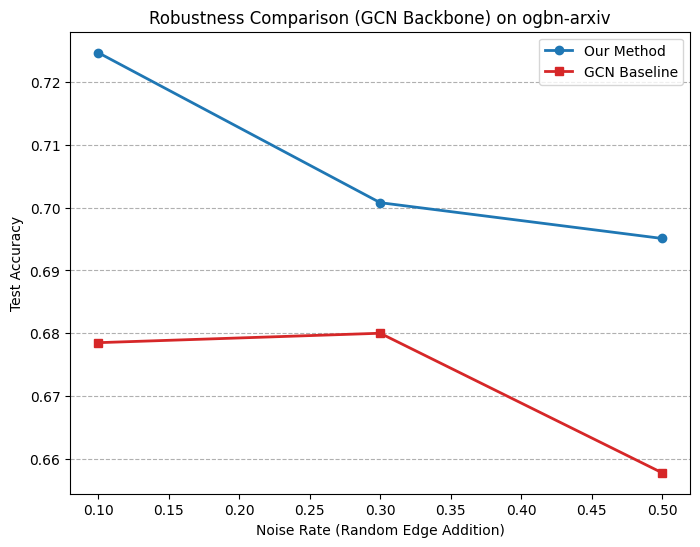

In [ ]:
# ogbn-arxiv robust test (GCN Version)

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from torch_geometric.nn import GCNConv, MessagePassing 
from torch_geometric.utils import negative_sampling, softmax, add_self_loops
from torch_geometric.loader import NeighborLoader 
import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator 
import matplotlib.pyplot as plt

# ==========================================
# 0. 鲁棒性全局配置
# ==========================================
NOISE_RATIOS = [0.0, 0.10,0.20,0.30,0.40,0.50,0.60] # 噪声比例
TEST_SEED = 1

# ==========================================
# 1. 核心架构组件 (完全同步 2.8 GCN new 主代码逻辑)
# ==========================================
class Config: 
    hidden_dim = 128; proj_dim = 256; hops = 2; epochs = 40 
    soft_end = 15; lr_init = 0.001; batch_size = 512
    target_sparsity = 0.30; lambda_max = 1.0; link_weight = 0.4; weight_decay = 5e-4

class SubgraphEnhancer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, weights):
        x = self.lin(x)
        norm_weights = softmax(weights, edge_index[1], num_nodes=x.size(0))
        return self.propagate(edge_index, x=x, weights=norm_weights)
    def message(self, x_j, weights):
        return weights.view(-1, 1) * x_j

class BilinearSampler(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.W = nn.Parameter(torch.Tensor(proj_dim, proj_dim))
        self.bias = nn.Parameter(torch.Tensor([3.0])) 
        nn.init.xavier_uniform_(self.W)
    def forward(self, h_i, h_j):
        z_i, z_j = self.proj(h_i), self.proj(h_j)
        score = torch.sum((z_i @ self.W) * z_j, dim=-1) + self.bias
        return torch.clamp(score, min=-10.0, max=10.0)

class NeuralRecursiveSystem(torch.nn.Module):
    def __init__(self, in_size, hidden_size, out_size, hops=2, tau=0.8): 
        super().__init__()
        self.total_hidden = hidden_size * 8
        self.label_emb = nn.Embedding(out_size + 1, self.total_hidden)
        
        # [同步修改] 将 GAT 改为 GCN
        self.gcn1 = GCNConv(self.total_hidden, self.total_hidden)
        self.bn1 = nn.BatchNorm1d(self.total_hidden)
        self.gcn2 = GCNConv(self.total_hidden, self.total_hidden)
        self.bn2 = nn.BatchNorm1d(self.total_hidden)
        
        self.sampler_net = BilinearSampler(in_dim=self.total_hidden, proj_dim=Config.proj_dim)
        self.enhancer = SubgraphEnhancer(self.total_hidden, self.total_hidden)
        self.bn_enh = nn.BatchNorm1d(self.total_hidden)
        self.res_lin = nn.Linear(in_size, self.total_hidden)
        self.link_predictor = nn.Sequential(nn.Linear(self.total_hidden*2, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(self.total_hidden, hidden_size * 4), nn.BatchNorm1d(hidden_size * 4),
                                        nn.ReLU(), nn.Dropout(0.3), nn.Linear(hidden_size * 4, out_size))
        self.hops, self.tau = hops, tau

    def get_neural_recursive_weights(self, h, edge_index, start_mask, hard=True):
        row, col = edge_index 
        logits_raw = self.sampler_net(h[row], h[col])
        sampling_logits = torch.stack([torch.zeros_like(logits_raw), logits_raw], dim=-1)
        sampling_mask = F.gumbel_softmax(sampling_logits, tau=self.tau, hard=hard, dim=-1)[:, 1]
        active_nodes = start_mask.float()
        final_weights = torch.zeros(edge_index.size(1), device=edge_index.device)
        for _ in range(self.hops):
            edge_active_mask = active_nodes[col] 
            current_step_weights = sampling_mask * edge_active_mask
            final_weights = torch.max(final_weights, current_step_weights)
            new_active_nodes = torch.zeros(h.size(0), device=edge_index.device)
            new_active_nodes.scatter_add_(0, row, current_step_weights)
            active_nodes = torch.clamp(new_active_nodes, 0, 1) if not hard else (new_active_nodes > 1e-5).float()
        return final_weights, logits_raw

    def forward(self, x, edge_index, y_label, target_mask, hard=True):
        x_proj = self.res_lin(x); y_emb = self.label_emb(y_label); x_fused = x_proj + y_emb 
        # [同步修改] GCN 前向传播
        h1 = F.elu(self.bn1(self.gcn1(x_fused, edge_index)) + y_emb) 
        h_base = F.elu(self.bn2(self.gcn2(h1, edge_index)) + x_proj) 
        weights, logits_raw = self.get_neural_recursive_weights(h_base, edge_index, target_mask, hard=hard)
        h_enhanced = h_base
        for _ in range(self.hops):
            h_enhanced = F.elu(self.bn_enh(h_enhanced + self.enhancer(h_enhanced, edge_index, weights))) 
        return F.log_softmax(self.classifier(h_enhanced), dim=1), self.link_predictor(torch.cat([h_enhanced[edge_index[0]], h_enhanced[edge_index[1]]], -1)).squeeze(), h_enhanced, weights, logits_raw.detach()

# --- Baseline GCN (同步修改) ---
class GCN_Vanilla(torch.nn.Module):
    def __init__(self, in_size, hidden_dim, out_size):
        super().__init__()
        self.res_lin = nn.Linear(in_size, hidden_dim * 8)
        self.conv1 = GCNConv(hidden_dim * 8, hidden_dim * 8)
        self.bn1 = nn.BatchNorm1d(hidden_dim * 8)
        self.conv2 = GCNConv(hidden_dim * 8, hidden_dim * 8)
        self.bn2 = nn.BatchNorm1d(hidden_dim * 8)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim * 8, hidden_dim * 4),
                                        nn.BatchNorm1d(hidden_dim * 4), nn.ReLU(),
                                        nn.Dropout(0.3), nn.Linear(hidden_dim * 4, out_size))
    def forward(self, x, edge_index):
        x_p = self.res_lin(x)
        x = F.elu(self.bn1(self.conv1(x_p, edge_index)))
        x = F.elu(self.bn2(self.conv2(x, edge_index))) + x_p
        return F.log_softmax(self.classifier(x), dim=1)

# ==========================================
# 2. 实验核心逻辑
# ==========================================
def inject_structure_noise(edge_index, num_nodes, noise_rate):
    if noise_rate <= 0: return edge_index
    num_noise = int(edge_index.size(1) * noise_rate)
    noise_edges = negative_sampling(edge_index, num_nodes=num_nodes, num_neg_samples=num_noise)
    return torch.cat([edge_index, noise_edges], dim=1)

def run_experiment(m_type, noise_rate, data, split_idx, device, evaluator):
    noisy_edges = inject_structure_noise(data.edge_index, data.num_nodes, noise_rate)
    noisy_edges, _ = add_self_loops(noisy_edges, num_nodes=data.num_nodes)
    data.edge_index = noisy_edges

    train_loader = NeighborLoader(data, num_neighbors=[20, 15], batch_size=Config.batch_size, 
                                  input_nodes=split_idx['train'], shuffle=True, num_workers=4, persistent_workers=True)
    test_loader = NeighborLoader(data, num_neighbors=[-1, -1], batch_size=Config.batch_size, 
                                 input_nodes=split_idx['test'], shuffle=False, num_workers=4, persistent_workers=True)

    if m_type == 'Ours':
        model = NeuralRecursiveSystem(data.num_features, 128, 40).to(device)
        optimizer = torch.optim.Adam([
            {'params': [p for n, p in model.named_parameters() if 'sampler_net' not in n], 'lr': Config.lr_init},
            {'params': model.sampler_net.parameters(), 'lr': Config.lr_init * 0.1}
        ], weight_decay=Config.weight_decay)
    else:
        model = GCN_Vanilla(data.num_features, 128, 40).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=Config.lr_init, weight_decay=Config.weight_decay)

    best_test_acc = 0
    for epoch in range(1, Config.epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            if m_type == 'Ours':
                y_in = batch.y.squeeze().clone(); y_in[:batch.batch_size] = 40
                mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device); mask[:batch.batch_size] = True
                lp, link_pos, h_enh, ws, _ = model(batch.x, batch.edge_index, y_in, mask, hard=(epoch > Config.soft_end))
                loss = F.nll_loss(lp[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
                neg_e = negative_sampling(batch.edge_index, num_nodes=batch.num_nodes).to(device)
                link_neg = model.link_predictor(torch.cat([h_enh[neg_e[0]], h_enh[neg_e[1]]], -1)).squeeze()
                loss += Config.link_weight * (F.binary_cross_entropy(link_pos, torch.ones_like(link_pos)) + F.binary_cross_entropy(link_neg, torch.zeros_like(link_neg)))
                loss += Config.lambda_max * F.l1_loss(ws.mean(), torch.tensor(Config.target_sparsity, device=device))
            else:
                out = model(batch.x, batch.edge_index)
                loss = F.nll_loss(out[:batch.batch_size], batch.y.squeeze()[:batch.batch_size])
            loss.backward(); optimizer.step()

        if epoch % 10 == 0:
            model.eval(); y_preds = []
            with torch.no_grad():
                for batch in test_loader:
                    batch = batch.to(device)
                    if m_type == 'Ours':
                        y_in = batch.y.squeeze().clone(); y_in[:batch.batch_size] = 40
                        mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device); mask[:batch.batch_size] = True
                        out, _, _, _, _ = model(batch.x, batch.edge_index, y_in, mask, hard=True)
                    else:
                        out = model(batch.x, batch.edge_index)
                    y_preds.append(out[:batch.batch_size].argmax(dim=-1).cpu())
            acc = evaluator.eval({'y_true': data.y[split_idx['test']].numpy(), 'y_pred': torch.cat(y_preds).numpy().reshape(-1,1)})['acc']
            best_test_acc = max(best_test_acc, acc)
            print(f"[{m_type} Noise:{noise_rate:.2f}] Ep:{epoch:03d} TestAcc:{acc:.4f}", end='\r')
            
    return best_test_acc

# ==========================================
# 3. 主循环与绘图
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='./data', transform=T.ToUndirected())
    data_orig = dataset[0]
    split_idx = dataset.get_idx_split()
    evaluator = Evaluator(name='ogbn-arxiv')
    
    results_ours, results_gcn = [], []
    
    for p in NOISE_RATIOS:
        print(f"\n--- Testing Noise Level: {p*100:.0f}% ---")
        torch.manual_seed(TEST_SEED)
        acc_o = run_experiment('Ours', p, data_orig.clone(), split_idx, device, evaluator)
        results_ours.append(acc_o)
        
        torch.manual_seed(TEST_SEED)
        acc_g = run_experiment('GCN', p, data_orig.clone(), split_idx, device, evaluator)
        results_gcn.append(acc_g)

    # 绘图
    plt.figure(figsize=(8, 6))
    plt.plot(NOISE_RATIOS, results_ours, marker='o', color='#1f77b4', label='Our Method ', linewidth=2)
    plt.plot(NOISE_RATIOS, results_gcn, marker='s', color='#d62728', label='GCN Baseline', linewidth=2)
    plt.xlabel('Noise Rate (Random Edge Addition)'); plt.ylabel('Test Accuracy')
    plt.title('Robustness Comparison (GCN Backbone) on ogbn-arxiv'); plt.legend(); plt.grid(axis='y', linestyle='--')
    plt.savefig('robustness_gcn_result.png'); plt.show()